# **Diskretisasi, Transformasi & Normalisasi**
**Input:** `data/interim/data_eda_bersih.csv` 

---
## Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, PowerTransformer
)
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
# Load data hasil EDA + data cuaca kemudian merge
import os

# Load polusi dari EDA (sudah daily aggregation)
try:
    df = pd.read_csv('data/interim/data_eda_bersih.csv')
    print('Loaded: data/interim/data_eda_bersih.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('../data/interim/data_eda_bersih.csv')
        print('Loaded: ../data/interim/data_eda_bersih.csv')
    except FileNotFoundError:
        df = pd.read_csv('data/processed/polusi clean test.csv')
        print('Loaded: data/processed/polusi clean test.csv')

# Parsing datetime jika ada
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Load cuaca
PATH_CUACA = r'\fatiyya\KULIAH\TUGAS KULIAH\SEMESTER 6\DAMING\project-daming\data\data cuaca\bundaran_hi 2022-01-01 to 2024-12-31.csv'

with open(PATH_CUACA, 'r', encoding='utf-8') as f:
    lines = f.readlines()

headers_cuaca = ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 
                 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'preciptype', 
                 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure',
                 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
                 'severerisk', 'sunrise', 'sunset', 'moonphase', 'conditions', 'description',
                 'icon', 'stations']

data_rows = []
for line in lines[1:]:
    line = line.strip()
    if not line:
        continue
    
    parts = line.split(',')
    lat_part = parts[0].strip(' "')
    
    try:
        lat = float(lat_part)
        lon = float(parts[1].strip())
        date_str = parts[2].strip()
        date_obj = pd.to_datetime(date_str, format='%m/%d/%Y')
        
        row_data = {
            'datetime_cuaca': date_obj,
            'lat': lat,
            'lon': lon
        }
        
        for i, header in enumerate(headers_cuaca):
            idx = i + 3
            if idx < len(parts):
                val_str = parts[idx].strip().strip('"')
                if val_str and val_str != '':
                    try:
                        row_data[header] = float(val_str)
                    except:
                        row_data[header] = val_str if val_str else None
                else:
                    row_data[header] = None
            else:
                row_data[header] = None
        
        data_rows.append(row_data)
    except Exception as e:
        continue

df_cuaca = pd.DataFrame(data_rows)
print(f'Loaded: {len(df_cuaca)} rows dari bundaran_hi cuaca')

# Merge polusi dengan cuaca berdasarkan tanggal
if 'datetime' in df.columns and 'datetime_cuaca' in df_cuaca.columns:
    # Buat kolom tanggal untuk merge (hanya bagian date)
    df['tanggal_merge'] = df['datetime'].dt.date
    df_cuaca['tanggal_merge'] = df_cuaca['datetime_cuaca'].dt.date
    
    # Merge
    df = pd.merge(df, df_cuaca.drop(columns=['datetime_cuaca', 'lat', 'lon']), 
                   left_on='tanggal_merge', right_on='tanggal_merge', how='left')
    df = df.drop(columns=['tanggal_merge'])
    print(f'Merge complete: {df.shape[0]} rows × {df.shape[1]} columns')

print(f'\n DataFrame:')
print(f'   Shape: {df.shape}')
print(f'   Kolom (15 pertama): {list(df.columns[:15])}')
print(f'   Total kolom: {df.shape[1]}')
display(df.head(3))


Loaded: data/interim/data_eda_bersih.csv
Loaded: 1096 rows dari bundaran_hi cuaca
Merge complete: 210624 rows × 51 columns

 DataFrame:
   Shape: (210624, 51)
   Kolom (15 pertama): ['Waktu', 'ISPU PM2.5', 'Status By PM10', 'Status By PM2.5', 'Status By SO2', 'Status By CO', 'Status By O3', 'Status By NO2', 'Critical Parameter', 'Overall ISPU Status', 'tanggal', 'station', 'datetime', 'tahun', 'bulan']
   Total kolom: 51


,Waktu,ISPU PM2.5,Status By PM10,Status By PM2.5,Status By SO2,Status By CO,Status By O3,Status By NO2,Critical Parameter,Overall ISPU Status,tanggal,station,datetime,tahun,bulan,hari,jam,hari_minggu,nama_hari,ISPU PM2.5_is_outlier,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,00:00,74.0000,-,-,-,-,-,-,-,-,2022-01-01,Bundaran HI CSV,2022-01-01,2022,1,1,0,5,Saturday,0,32.3000,25.0000,28.6000,37.6000,25.0000,31.9000,24.0000,77.2000,0.4960,100.0000,8.3300,rain,0.0000,0.0000,37.1000,21.7000,261.8000,1009.6000,50.8000,6.7000,249.2000,20.6000,9.0000,NaN,2022-01-01T05:41:56,2022-01-01T18:10:21,0.9500,Rain,Partially cloudy,Partly cloudy throughout the day with rain cle...,rain
1,00:00,73.0000,-,-,-,-,-,-,-,-,2022-01-01,Jakarta GBK CSV,2022-01-01,2022,1,1,0,5,Saturday,0,32.3000,25.0000,28.6000,37.6000,25.0000,31.9000,24.0000,77.2000,0.4960,100.0000,8.3300,rain,0.0000,0.0000,37.1000,21.7000,261.8000,1009.6000,50.8000,6.7000,249.2000,20.6000,9.0000,NaN,2022-01-01T05:41:56,2022-01-01T18:10:21,0.9500,Rain,Partially cloudy,Partly cloudy throughout the day with rain cle...,rain
2,00:00,70.2847,-,-,-,-,-,-,-,-,2022-01-01,US Embassy 1 CSV,2022-01-01,2022,1,1,0,5,Saturday,0,32.3000,25.0000,28.6000,37.6000,25.0000,31.9000,24.0000,77.2000,0.4960,100.0000,8.3300,rain,0.0000,0.0000,37.1000,21.7000,261.8000,1009.6000,50.8000,6.7000,249.2000,20.6000,9.0000,NaN,2022-01-01T05:41:56,2022-01-01T18:10:21,0.9500,Rain,Partially cloudy,Partly cloudy throughout the day with rain cle...,rain


In [4]:
# Identifikasi kolom polutan, cuaca numerik, dan kategorikal
# Kolom polutan dimulai dengan prefix 'ISPU '

POLLUTANTS = [col for col in df.columns if col.startswith('ISPU ')]

CUACA_NUMERIK = ['tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity',
                  'precip', 'precipprob', 'windgust', 'windspeed', 'winddir',
                  'sealevelpressure', 'cloudcover', 'visibility',
                  'solarradiation', 'solarenergy', 'uvindex']
CUACA_NUMERIK = [col for col in CUACA_NUMERIK if col in df.columns]

CUACA_KATEGORIKAL = ['conditions', 'icon', 'preciptype']
CUACA_KATEGORIKAL = [col for col in CUACA_KATEGORIKAL if col in df.columns]

print('IDENTIFIKASI KOLOM')
print(f'Polutan aktif ({len(POLLUTANTS)} kolom):')
for col in POLLUTANTS:
    print(f'   - {col}')

print(f'\nCuaca numerik ({len(CUACA_NUMERIK)} kolom):')
for col in CUACA_NUMERIK:
    print(f'   - {col}')

print(f'\nCuaca kategorikal ({len(CUACA_KATEGORIKAL)} kolom):')
for col in CUACA_KATEGORIKAL:
    print(f'   - {col}')

if len(POLLUTANTS) == 0 or len(CUACA_NUMERIK) == 0:
    print('\n Ada kategori fitur yang kosong')


IDENTIFIKASI KOLOM
Polutan aktif (2 kolom):
   - ISPU PM2.5
   - ISPU PM2.5_is_outlier

Cuaca numerik (17 kolom):
   - tempmax
   - tempmin
   - temp
   - feelslike
   - dew
   - humidity
   - precip
   - precipprob
   - windgust
   - windspeed
   - winddir
   - sealevelpressure
   - cloudcover
   - visibility
   - solarradiation
   - solarenergy
   - uvindex

Cuaca kategorikal (3 kolom):
   - conditions
   - icon
   - preciptype


In [5]:
status_cols = [col for col in df.columns if col.startswith('Status By')]
print(f'Kolom Status: {status_cols}\n')

for col in status_cols:
    n_non_null = df[col].notna().sum()
    n_null = df[col].isna().sum()
    persen_isi = (n_non_null / len(df)) * 100
    
    print(f'{col}:')
    print(f'   Non-null: {n_non_null:,} ({persen_isi:.1f}%)')
    print(f'   Null/Kosong: {n_null:,} ({100-persen_isi:.1f}%)')
    
    if n_non_null > 0:
        print(f'   Unique Value: {df[col].nunique()}')
        print(f'   Contoh: {df[col].dropna().unique()[:5]}')
    else:
        print(f'KOSONG')
    print()


Kolom Status: ['Status By PM10', 'Status By PM2.5', 'Status By SO2', 'Status By CO', 'Status By O3', 'Status By NO2']

Status By PM10:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 4
   Contoh: ['-' 'Baik' 'Sedang' 'Tidak Sehat']

Status By PM2.5:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 5
   Contoh: ['-' 'Sedang' 'Baik' 'Tidak Sehat' 'Sangat Tidak Sehat']

Status By SO2:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 3
   Contoh: ['-' 'Baik' 'Sedang']

Status By CO:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 3
   Contoh: ['-' 'Baik' 'Sedang']

Status By O3:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 4
   Contoh: ['-' 'Baik' 'Sedang' 'Tidak Sehat']

Status By NO2:
   Non-null: 210,624 (100.0%)
   Null/Kosong: 0 (0.0%)
   Unique Value: 5
   Contoh: ['-' 'Baik' 'Sedang' 'Tidak Sehat' 'Sangat Tidak Sehat']



---
## Diskretisasi (Mengkategorikan Level Polusi)

1. **Standar ISPU** (Indeks Standar Pencemar Udara Indonesia)
2. **Equal-width binning** (pd.cut)
3. **Equal-frequency binning** (pd.qcut / quantile-based)

In [6]:
# METODE 1: ISPU Indonesia
# Standar dari KLHK (Kementerian Lingkungan Hidup dan Kehutanan)
# Referensi: PerMen LHK No. 14 Tahun 2020

def ispu_pm25(nilai):
    """Kategorisasi PM2.5 berdasarkan ISPU Indonesia."""
    if pd.isna(nilai):     return np.nan
    elif nilai <= 15.5:    return 'Baik'
    elif nilai <= 55.4:    return 'Sedang'
    elif nilai <= 150.4:   return 'Tidak Sehat'
    elif nilai <= 250.4:   return 'Sangat Tidak Sehat'
    else:                  return 'Berbahaya'

def ispu_pm10(nilai):
    """Kategorisasi PM10 berdasarkan ISPU Indonesia."""
    if pd.isna(nilai):     return np.nan
    elif nilai <= 50:      return 'Baik'
    elif nilai <= 150:     return 'Sedang'
    elif nilai <= 350:     return 'Tidak Sehat'
    elif nilai <= 420:     return 'Sangat Tidak Sehat'
    else:                  return 'Berbahaya'

def ispu_so2(nilai):
    """Kategorisasi SO2 berdasarkan ISPU Indonesia (µg/m³)."""
    if pd.isna(nilai):     return np.nan
    elif nilai <= 52.4:    return 'Baik'
    elif nilai <= 180.4:   return 'Sedang'
    elif nilai <= 400.4:   return 'Tidak Sehat'
    elif nilai <= 800.4:   return 'Sangat Tidak Sehat'
    else:                  return 'Berbahaya'

def ispu_co(nilai):
    """Kategorisasi CO berdasarkan ISPU Indonesia (µg/m³)."""
    if pd.isna(nilai):      return np.nan
    elif nilai <= 4000:     return 'Baik'
    elif nilai <= 8000:     return 'Sedang'
    elif nilai <= 15000:    return 'Tidak Sehat'
    elif nilai <= 30000:    return 'Sangat Tidak Sehat'
    else:                   return 'Berbahaya'

def ispu_o3(nilai):
    """Kategorisasi O3 berdasarkan ISPU Indonesia (µg/m³)."""
    if pd.isna(nilai):      return np.nan
    elif nilai <= 120:      return 'Baik'
    elif nilai <= 235:      return 'Sedang'
    elif nilai <= 400:      return 'Tidak Sehat'
    elif nilai <= 800:      return 'Sangat Tidak Sehat'
    else:                   return 'Berbahaya'

def ispu_no2(nilai):
    """Kategorisasi NO2 berdasarkan ISPU Indonesia (µg/m³)."""
    if pd.isna(nilai):      return np.nan
    elif nilai <= 80:       return 'Baik'
    elif nilai <= 200:      return 'Sedang'
    elif nilai <= 1130:     return 'Tidak Sehat'
    elif nilai <= 2260:     return 'Sangat Tidak Sehat'
    else:                   return 'Berbahaya'

# Mapping polutan dengan fungsi ISPU
ispu_func_mapping = {
    'PM2.5': ispu_pm25, 
    'PM10': ispu_pm10, 
    'SO2': ispu_so2,
    'CO': ispu_co, 
    'O3': ispu_o3, 
    'NO2': ispu_no2
}

df_disc = df.copy()
ispu_cols_created = []

for pol in POLLUTANTS:
    # Extract nama polutan dari kolom (remove 'ISPU ' prefix jika ada)
    pol_name = pol.replace('ISPU ', '').strip()
    
    # Cari fungsi yang cocok
    func = ispu_func_mapping.get(pol_name)
    
    if func and pol in df_disc.columns:
        df_disc[f'{pol}_kategori'] = df_disc[pol].apply(func)
        ispu_cols_created.append(f'{pol}_kategori')
        print(f'{pol} → kategori ISPU')
        print(f'Distribusi:')
        print(df_disc[f'{pol}_kategori'].value_counts().to_string())
        print()

if ispu_cols_created:
    print(f'Total {len(ispu_cols_created)} kolom kategori ISPU')
else:
    print('Tidak ada kolom polutan yang bisa di-kategorisasi dengan ISPU')


ISPU PM2.5 → kategori ISPU
Distribusi:
ISPU PM2.5_kategori
Tidak Sehat           167372
Sedang                 34881
Baik                    8141
Sangat Tidak Sehat       217
Berbahaya                 13

Total 1 kolom kategori ISPU


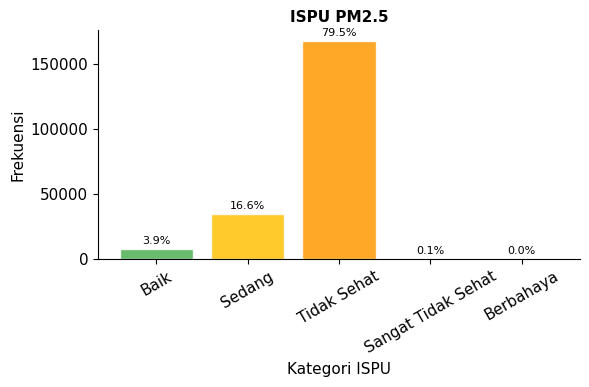

In [7]:
# Visualisasi distribusi kategori ISPU
ispu_cols = [f'{pol}_kategori' for pol in POLLUTANTS if f'{pol}_kategori' in df_disc.columns]
urutan_ispu = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
warna_ispu = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#9C27B0']

if ispu_cols:
    n_cols = 3
    n_rows = (len(ispu_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    if n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(ispu_cols):
        ax = axes[i]
        counts = df_disc[col].value_counts()
        # Urutkan sesuai level ISPU
        counts = counts.reindex([k for k in urutan_ispu if k in counts.index])
        colors = [warna_ispu[urutan_ispu.index(k)] for k in counts.index]
        
        bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.85, edgecolor='white')
        ax.set_title(col.replace('_kategori', ''), fontweight='bold', fontsize=11)
        ax.set_xlabel('Kategori ISPU')
        ax.set_ylabel('Frekuensi')
        ax.tick_params(axis='x', rotation=30)
        
        # Tambah label persentase
        total = counts.sum()
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                    f'{val/total*100:.1f}%', ha='center', va='bottom', fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    

    plt.tight_layout()
    plt.savefig('outputs/distribusi_ispu.png', dpi=150, bbox_inches='tight')
    plt.show()
    

In [8]:
# METODE 2: Equal-Width Binning 
# Membagi rentang nilai menjadi interval sama besar
# ini lebih cocok pas distribusi nya merata

print('EQUAL-WIDTH BINNING (pd.cut)')
for pol in POLLUTANTS:
    if pol in df_disc.columns:
        df_disc[f'{pol}_bin_width'] = pd.cut(df_disc[pol], bins=5,
                                              labels=['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi'])
        print(f'{pol}:')
        value_counts = df_disc[f'{pol}_bin_width'].value_counts().sort_index()
        print(value_counts.to_string())
        print()

if POLLUTANTS:
    print('Catatan: Equal-width binning bisa menghasilkan kelas yang sangat tidak seimbang')
    print('jika data right-skewed. Cek apakah ada kelas dengan sangat sedikit data.')

EQUAL-WIDTH BINNING (pd.cut)
ISPU PM2.5:
ISPU PM2.5_bin_width
Sangat Rendah     45258
Rendah           159980
Sedang             5273
Tinggi               82
Sangat Tinggi        31

ISPU PM2.5_is_outlier:
ISPU PM2.5_is_outlier_bin_width
Sangat Rendah    200748
Rendah                0
Sedang                0
Tinggi                0
Sangat Tinggi      9876

Catatan: Equal-width binning bisa menghasilkan kelas yang sangat tidak seimbang
jika data right-skewed. Cek apakah ada kelas dengan sangat sedikit data.


In [9]:
# METODE 3: Equal-Frequency Binning (Quantile-based)
# Setiap bin memiliki jumlah data yang sama
# Lebih robust untuk data skewed

print('EQUAL-FREQUENCY BINNING (pd.qcut)')
for pol in POLLUTANTS:
    if pol in df_disc.columns:
        try:
            df_disc[f'{pol}_bin_freq'] = pd.qcut(df_disc[pol], q=5,
                                                   labels=['Q1','Q2','Q3','Q4','Q5'],
                                                   duplicates='drop')
            print(f'{pol}: dibagi 5 kuantil')
            print(df_disc[f'{pol}_bin_freq'].value_counts().sort_index().to_string())
        except Exception as e:
            print(f'{pol}: {e}')
        print()

print('Equal-frequency memastikan setiap bin berisi jumlah data yang sama.')
print('Berguna untuk algoritma klasifikasi agar kelas seimbang.')

EQUAL-FREQUENCY BINNING (pd.qcut)
ISPU PM2.5: dibagi 5 kuantil
ISPU PM2.5_bin_freq
Q1    42386
Q2    41867
Q3    42121
Q4    42125
Q5    42125

ISPU PM2.5_is_outlier: Bin labels must be one fewer than the number of bin edges

Equal-frequency memastikan setiap bin berisi jumlah data yang sama.
Berguna untuk algoritma klasifikasi agar kelas seimbang.


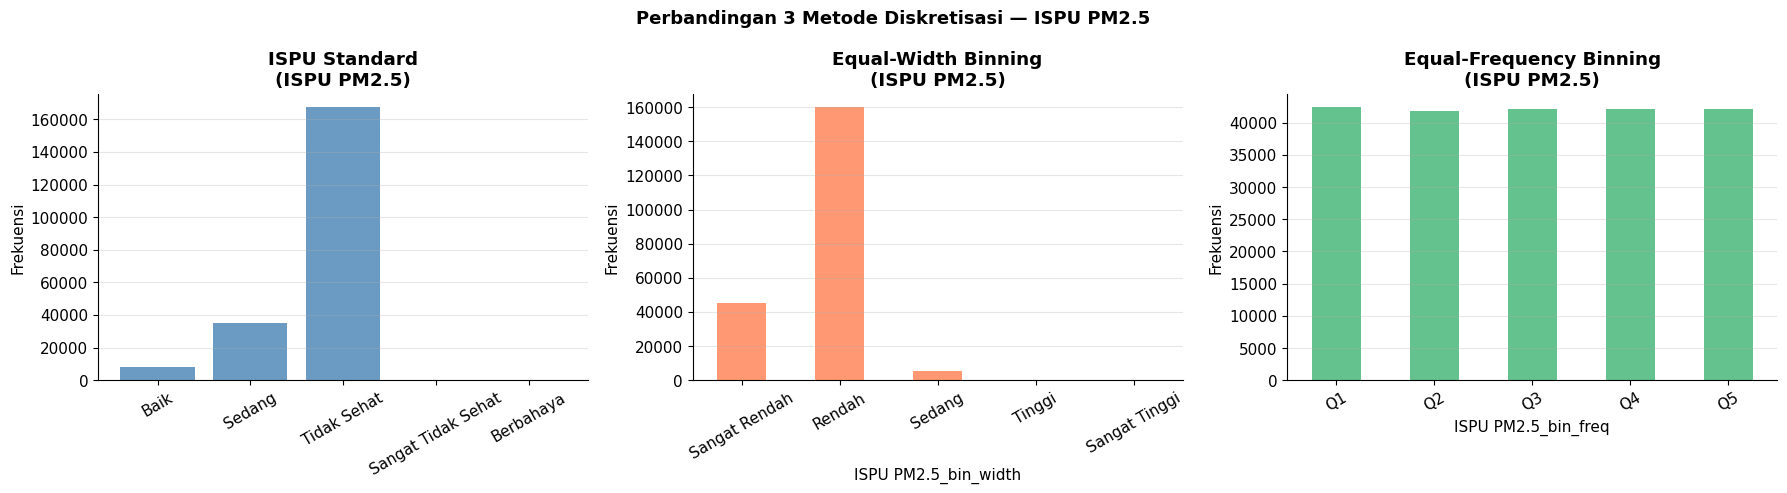

In [10]:
# Perbandingan ketiga metode diskretisasi
pol_contoh = POLLUTANTS[0] 

if pol_contoh in df_disc.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # ISPU
    ispu_col = f'{pol_contoh}_kategori'
    if ispu_col in df_disc.columns:
        counts = df_disc[ispu_col].value_counts().reindex([k for k in urutan_ispu if k in df_disc[ispu_col].values])
        axes[0].bar(counts.index, counts.values, color='steelblue', alpha=0.8)
        axes[0].set_title(f'ISPU Standard\n({pol_contoh})', fontweight='bold')
        axes[0].tick_params(axis='x', rotation=30)
    
    # Equal-width
    bin_w_col = f'{pol_contoh}_bin_width'
    if bin_w_col in df_disc.columns:
        df_disc[bin_w_col].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', alpha=0.8)
        axes[1].set_title(f'Equal-Width Binning\n({pol_contoh})', fontweight='bold')
        axes[1].tick_params(axis='x', rotation=30)
    
    # Equal-frequency
    bin_f_col = f'{pol_contoh}_bin_freq'
    if bin_f_col in df_disc.columns:
        df_disc[bin_f_col].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumseagreen', alpha=0.8)
        axes[2].set_title(f'Equal-Frequency Binning\n({pol_contoh})', fontweight='bold')
        axes[2].tick_params(axis='x', rotation=30)
    
    for ax in axes:
        ax.set_ylabel('Frekuensi')
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Perbandingan 3 Metode Diskretisasi — {pol_contoh}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/perbandingan_diskretisasi.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Transformasi (Mengatasi Distribusi Skewed)

In [11]:
# Cek skewness sebelum transformasi
print('SKEWNESS SEBELUM TRANSFORMASI')
skewness_before = df[POLLUTANTS].skew().round(3)
for col, skew in skewness_before.items():
    if abs(skew) > 1:
        level = 'Tinggi → PERLU transformasi'
    elif abs(skew) > 0.5:
        level = 'Sedang → Opsional transformasi'
    else:
        level = 'Rendah → Transformasi opsional'
    print(f'   {col:8s}: {skew:7.3f} | {level}')

SKEWNESS SEBELUM TRANSFORMASI
   ISPU PM2.5:  -0.620 | Sedang → Opsional transformasi
   ISPU PM2.5_is_outlier:   4.287 | Tinggi → PERLU transformasi


In [12]:
# Penerapan transformasi dan Perbandingan
df_transform = df[POLLUTANTS].copy()

hasil_transformasi = []

for col in POLLUTANTS:
    data = df_transform[col].dropna()
    skew_original = data.skew()
    
    # Log transform
    log_data = np.log1p(data)  # log(x+1) untuk hindari log(0)
    skew_log = log_data.skew()
    df_transform[f'{col}_log'] = np.log1p(df_transform[col])
    
    # Square root transform
    sqrt_data = np.sqrt(data.clip(lower=0))  # clip agar tidak ada negatif
    skew_sqrt = sqrt_data.skew()
    df_transform[f'{col}_sqrt'] = np.sqrt(df_transform[col].clip(lower=0))
    
    # Yeo-Johnson (dapat menangani nilai 0 dan negatif)
    try:
        pt = PowerTransformer(method='yeo-johnson')
        yj_data = pt.fit_transform(data.values.reshape(-1, 1)).flatten()
        skew_yj = pd.Series(yj_data).skew()
        df_transform[f'{col}_yj'] = pt.transform(
            df_transform[[col]].fillna(df_transform[col].median()).values
        ).flatten()
    except Exception:
        skew_yj = np.nan
    
    # Box-Cox (hanya untuk nilai positif)
    try:
        data_pos = data[data > 0]
        bc_data, lambda_val = stats.boxcox(data_pos)
        skew_bc = pd.Series(bc_data).skew()
    except Exception:
        skew_bc = np.nan
        lambda_val = np.nan
    
    hasil_transformasi.append({
        'Polutan': col,
        'Original': round(skew_original, 3),
        'Log(x+1)': round(skew_log, 3),
        'Sqrt': round(skew_sqrt, 3),
        'Yeo-Johnson': round(skew_yj, 3) if not np.isnan(skew_yj) else 'N/A',
        'Box-Cox': round(skew_bc, 3) if not np.isnan(skew_bc) else 'N/A',
        'Box-Cox λ': round(lambda_val, 3) if not np.isnan(lambda_val) else 'N/A',
    })

hasil_df = pd.DataFrame(hasil_transformasi).set_index('Polutan')
print('PERBANDINGAN SKEWNESS SEBELUM & SESUDAH TRANSFORMASI')
print('(Nilai mendekati 0 = distribusi lebih normal)')
display(hasil_df)

print('\n untuk pilih transformasi:')
print('   - Pilih transformasi yang memberikan skewness paling mendekati 0')
print('   - Log(x+1) → umum & mudah diinterpretasi untuk polusi')
print('   - Yeo-Johnson → otomatis & robust, baik untuk pipeline scikit-learn')
print('   - Jika skewness sudah < 1 setelah log → cukup gunakan log')

PERBANDINGAN SKEWNESS SEBELUM & SESUDAH TRANSFORMASI
(Nilai mendekati 0 = distribusi lebih normal)


,Original,Log(x+1),Sqrt,Yeo-Johnson,Box-Cox,Box-Cox λ
Polutan,,,,,,
ISPU PM2.5,-0.6200,-4.0040,-2.4300,-0.1710,0.0960,1.0070
ISPU PM2.5_is_outlier,4.2870,4.2870,4.2870,4.2870,N/A,N/A



 untuk pilih transformasi:
   - Pilih transformasi yang memberikan skewness paling mendekati 0
   - Log(x+1) → umum & mudah diinterpretasi untuk polusi
   - Yeo-Johnson → otomatis & robust, baik untuk pipeline scikit-learn
   - Jika skewness sudah < 1 setelah log → cukup gunakan log


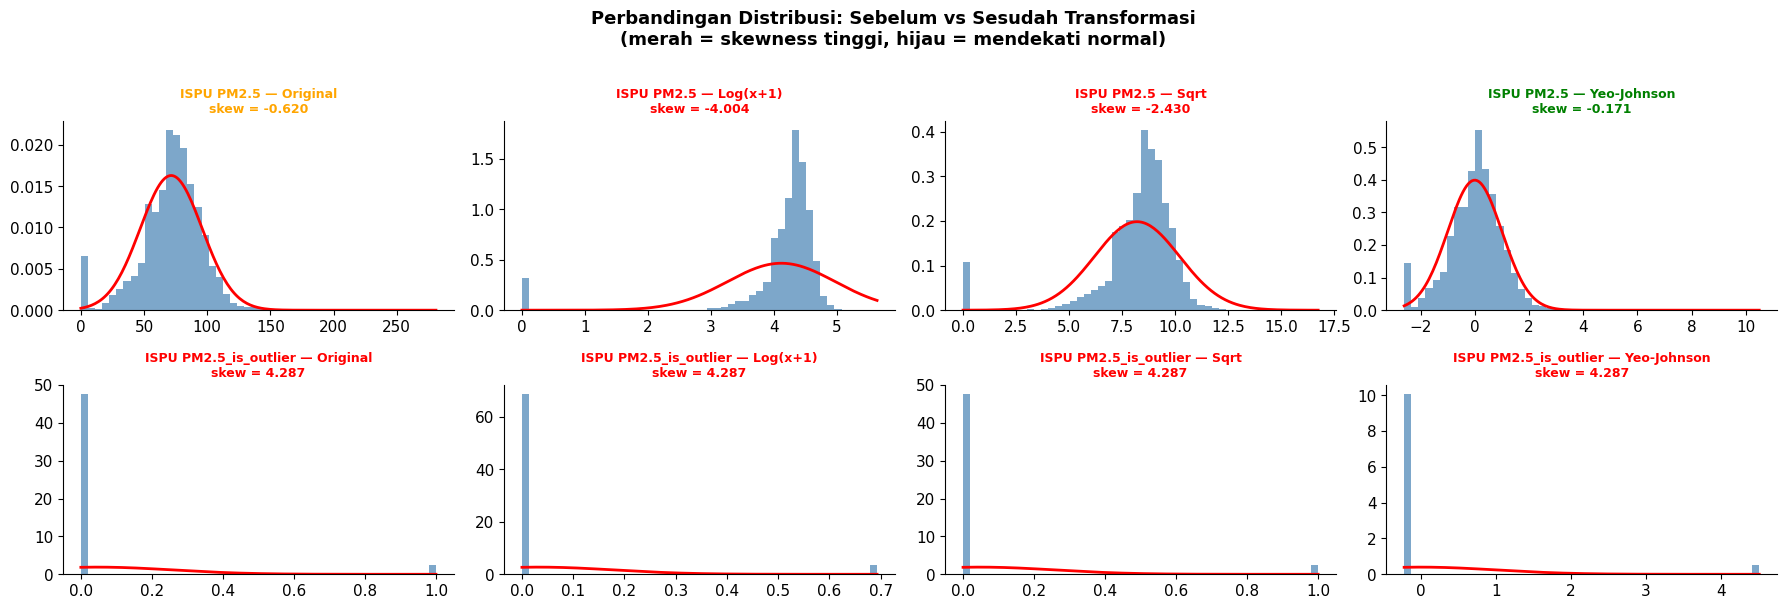

In [13]:
# Visualisasi: sebelum vs sesudah transformasi
pol_visualisasi = POLLUTANTS[:4]  # ambil 4 polutan pertama sebagai contoh

fig, axes = plt.subplots(len(pol_visualisasi), 4, figsize=(18, len(pol_visualisasi) * 3))

if len(pol_visualisasi) == 1:
    axes = axes.reshape(1, -1)

transform_names = ['Original', 'Log(x+1)', 'Sqrt', 'Yeo-Johnson']

for i, pol in enumerate(pol_visualisasi):
    if pol not in df.columns:
        continue
    
    data_ori  = df[pol].dropna()
    data_log  = np.log1p(data_ori)
    data_sqrt = np.sqrt(data_ori.clip(lower=0))
    
    try:
        pt = PowerTransformer(method='yeo-johnson')
        data_yj = pd.Series(pt.fit_transform(data_ori.values.reshape(-1,1)).flatten())
    except:
        data_yj = data_ori
    
    datasets = [data_ori, data_log, data_sqrt, data_yj]
    
    for j, (data, name) in enumerate(zip(datasets, transform_names)):
        ax = axes[i][j]
        ax.hist(data, bins=50, color='steelblue', alpha=0.7, density=True)
        
        # Kurva normal
        mu, sigma = data.mean(), data.std()
        if sigma > 0:
            x = np.linspace(data.min(), data.max(), 200)
            ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
        
        skew_val = data.skew()
        title_col = 'red' if abs(skew_val) > 1 else 'orange' if abs(skew_val) > 0.5 else 'green'
        ax.set_title(f'{pol} — {name}\nskew = {skew_val:.3f}', 
                     fontweight='bold', color=title_col, fontsize=9)

plt.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Transformasi\n(merah = skewness tinggi, hijau = mendekati normal)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/perbandingan_transformasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Log(x+1)

df_processed = df.copy()

TRANSFORMASI_DIPILIH = {}  # akan diisi otomatis

for col in POLLUTANTS:
    if col not in df.columns:
        continue
    
    skew = df[col].skew()
    
    if abs(skew) > 1:
        # Skewness tinggi → log transform
        df_processed[f'{col}_transformed'] = np.log1p(df_processed[col].clip(lower=0))
        TRANSFORMASI_DIPILIH[col] = 'log1p'
        
    elif abs(skew) > 0.5:
        # Skewness sedang → sqrt
        df_processed[f'{col}_transformed'] = np.sqrt(df_processed[col].clip(lower=0))
        TRANSFORMASI_DIPILIH[col] = 'sqrt'
        
    else:
        # Hampir normal → tidak ditransformasi
        df_processed[f'{col}_transformed'] = df_processed[col]
        TRANSFORMASI_DIPILIH[col] = 'none'

print('TRANSFORMASI YANG DITERAPKAN')
for pol, metode in TRANSFORMASI_DIPILIH.items():
    skew_before = df[pol].skew()
    skew_after = df_processed[f'{pol}_transformed'].skew()
    print(f'   {pol:8s}: {metode:8s} | skew sebelum: {skew_before:6.3f} → sesudah: {skew_after:6.3f}')

TRANSFORMASI YANG DITERAPKAN
   ISPU PM2.5: sqrt     | skew sebelum: -0.620 → sesudah: -2.430
   ISPU PM2.5_is_outlier: log1p    | skew sebelum:  4.287 → sesudah:  4.287


---
## Normalisasi & Standarisasi

|  |  |  |
|---|---|---|
| **MinMaxScaler** | `(x-min)/(max-min)` | Data tanpa outlier, neural network |
| **StandardScaler** | `(x-mean)/std` | Distribusi normal, regresi linear |
| **RobustScaler** | `(x-median)/IQR` | **Data dengan outlier** |

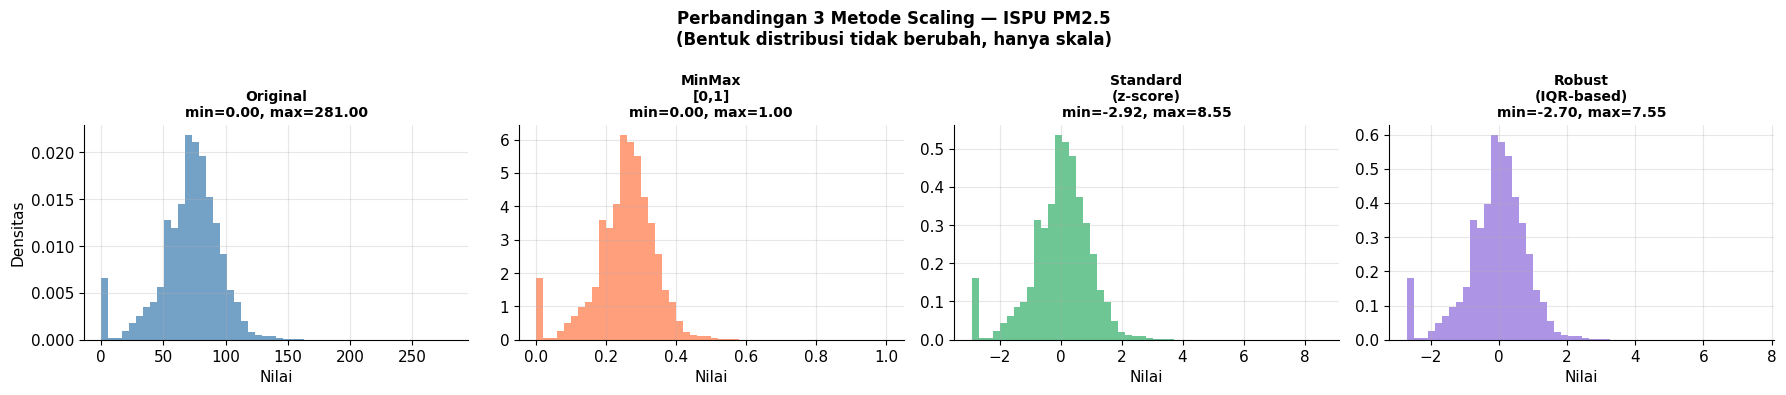

   MinMax   → semua nilai masuk rentang [0,1] tapi outlier tetap menekan distribusi
   Standard → rata-rata jadi 0, std jadi 1, sensitif terhadap outlier
   Robust   → menggunakan median & IQR, outlier tidak dominan


In [15]:
# Perbandingan visual 3 metode scaling 
pol_demo = POLLUTANTS[0] if POLLUTANTS else None

if pol_demo:
    data_demo = df[[pol_demo]].dropna()
    
    scalers = {
        'Original': data_demo[pol_demo].values,
        'MinMax\n[0,1]': MinMaxScaler().fit_transform(data_demo).flatten(),
        'Standard\n(z-score)': StandardScaler().fit_transform(data_demo).flatten(),
        'Robust\n(IQR-based)': RobustScaler().fit_transform(data_demo).flatten()
    }
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
    
    for ax, (nama, data), color in zip(axes, scalers.items(), colors):
        ax.hist(data, bins=50, color=color, alpha=0.75, density=True)
        ax.set_title(f'{nama}\nmin={data.min():.2f}, max={data.max():.2f}', 
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Nilai')
        ax.grid(alpha=0.3)
    
    axes[0].set_ylabel('Densitas')
    plt.suptitle(f'Perbandingan 3 Metode Scaling — {pol_demo}\n(Bentuk distribusi tidak berubah, hanya skala)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/perbandingan_scaling.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('   MinMax   → semua nilai masuk rentang [0,1] tapi outlier tetap menekan distribusi')
    print('   Standard → rata-rata jadi 0, std jadi 1, sensitif terhadap outlier')
    print('   Robust   → menggunakan median & IQR, outlier tidak dominan')

In [16]:
# Terapkan RobustScaler ke semua fitur numerik

# Kolom yang akan di-scale
polutan_transformed = [f'{col}_transformed' for col in POLLUTANTS 
                        if f'{col}_transformed' in df_processed.columns]

fitur_untuk_scale = polutan_transformed + CUACA_NUMERIK
fitur_untuk_scale = [col for col in fitur_untuk_scale if col in df_processed.columns]

# Inisialisasi scaler
scaler_robust = RobustScaler()

# Fit dan transform
data_to_scale = df_processed[fitur_untuk_scale].copy()

# Isi missing sebelum scaling (seharusnya sudah bersih dari notebook 03)
data_to_scale = data_to_scale.fillna(data_to_scale.median())

# Scaling
data_scaled = scaler_robust.fit_transform(data_to_scale)
df_scaled = pd.DataFrame(data_scaled, columns=fitur_untuk_scale, index=df_processed.index)

print(f'RobustScaler pada {len(fitur_untuk_scale)} fitur')
print('\nSTATISTIK SETELAH SCALING')
print('(Median seharusnya mendekati 0, IQR mendekati 1)')
stats_scaled = df_scaled.describe().T[['mean', '50%', 'std', 'min', 'max']]
stats_scaled.columns = ['Mean', 'Median', 'Std', 'Min', 'Max']
display(stats_scaled.round(4))

RobustScaler pada 19 fitur

STATISTIK SETELAH SCALING
(Median seharusnya mendekati 0, IQR mendekati 1)


,Mean,Median,Std,Min,Max
ISPU PM2.5_transformed,-0.2418,0.0000,1.2471,-5.3290,5.0554
ISPU PM2.5_is_outlier_transformed,0.0325,0.0000,0.1465,0.0000,0.6931
tempmax,-0.0928,0.0000,0.8283,-3.0000,2.5000
tempmin,-0.0636,0.0000,0.7849,-3.4545,2.9091
temp,-0.1139,0.0000,0.8114,-2.9231,2.0769
feelslike,-0.0306,0.0000,0.7781,-2.6800,2.4000
dew,-0.1252,0.0000,0.8200,-3.6923,1.4615
humidity,-0.0768,0.0000,0.7310,-2.3368,1.6421
precip,1.7988,0.0000,4.6202,-0.0087,54.4594
precipprob,-0.3610,0.0000,0.4803,-1.0000,0.0000


In [17]:
# Simpan scaler untuk digunakan saat inverse transform (evaluasi model)
import pickle, os
os.makedirs('outputs', exist_ok=True)

with open('outputs/scaler_robust.pkl', 'wb') as f:
    pickle.dump(scaler_robust, f)

with open('outputs/transformasi_config.pkl', 'wb') as f:
    pickle.dump(TRANSFORMASI_DIPILIH, f)

print('outputs/scaler_robust.pkl')
print('Config transformasi: outputs/transformasi_config.pkl')

# Contoh cara inverse transform (untuk interpretasi hasil model)
print('\n Cara inverse transform:')
print('   dengan open("outputs/scaler_robust.pkl", "rb") as f:')
print('       scaler = pickle.load(f)')
print('   prediksi_original = scaler.inverse_transform(prediksi_scaled)')

outputs/scaler_robust.pkl
Config transformasi: outputs/transformasi_config.pkl

 Cara inverse transform:
   dengan open("outputs/scaler_robust.pkl", "rb") as f:
       scaler = pickle.load(f)
   prediksi_original = scaler.inverse_transform(prediksi_scaled)


---
## Feature Engineering

In [18]:
# Fitur Temporal
df_final = df_processed.copy()

if 'datetime' in df_final.columns:
    print('FITUR TEMPORAL')
    
    # Fitur dasar waktu
    df_final['tahun']       = df_final['datetime'].dt.year
    df_final['bulan']       = df_final['datetime'].dt.month
    df_final['hari_bulan']  = df_final['datetime'].dt.day
    df_final['jam']         = df_final['datetime'].dt.hour
    df_final['hari_minggu'] = df_final['datetime'].dt.dayofweek  # 0=Senin
    df_final['minggu_tahun']= df_final['datetime'].dt.isocalendar().week.astype(int)
    df_final['hari_tahun']  = df_final['datetime'].dt.dayofyear
    
    # Fitur kategorikal waktu
    df_final['is_weekend']   = (df_final['hari_minggu'] >= 5).astype(int)
    df_final['is_rush_hour'] = df_final['jam'].isin([6,7,8,9,16,17,18,19]).astype(int)
    df_final['is_night']     = df_final['jam'].isin(range(22, 24)).astype(int) | \
                                df_final['jam'].isin(range(0, 5)).astype(int)
    
    # Musim Jakarta (berdasarkan bulan)
    def get_musim(bulan):
        if bulan in [11, 12, 1, 2, 3]:   return 'hujan'
        elif bulan in [4, 5, 10]:         return 'peralihan'
        else:                              return 'kemarau'
    
    df_final['musim'] = df_final['bulan'].apply(get_musim)
    
    # Encode siklus waktu dengan sin/cos 
    # catch sifat SIKLUS (setelah jam 23 kembali ke jam 0)
    df_final['jam_sin'] = np.sin(2 * np.pi * df_final['jam'] / 24)
    df_final['jam_cos'] = np.cos(2 * np.pi * df_final['jam'] / 24)
    df_final['bulan_sin'] = np.sin(2 * np.pi * df_final['bulan'] / 12)
    df_final['bulan_cos'] = np.cos(2 * np.pi * df_final['bulan'] / 12)
    df_final['hari_minggu_sin'] = np.sin(2 * np.pi * df_final['hari_minggu'] / 7)
    df_final['hari_minggu_cos'] = np.cos(2 * np.pi * df_final['hari_minggu'] / 7)
    
    fitur_temporal = ['tahun','bulan','hari_bulan','jam','hari_minggu','is_weekend',
                       'is_rush_hour','is_night','musim','jam_sin','jam_cos',
                       'bulan_sin','bulan_cos']
    print(f'   {fitur_temporal}')

FITUR TEMPORAL
   ['tahun', 'bulan', 'hari_bulan', 'jam', 'hari_minggu', 'is_weekend', 'is_rush_hour', 'is_night', 'musim', 'jam_sin', 'jam_cos', 'bulan_sin', 'bulan_cos']


In [19]:
# Lag Features & Rolling Statistics

if 'datetime' in df_final.columns:
    print('LAG FEATURES & ROLLING STATISTICS')
    
    # Sort berdasarkan waktu (WAJIB sebelum buat lag)
    df_final = df_final.sort_values('datetime').reset_index(drop=True)
    
    KOLOM_LOKASI = 'STATION'  
    
    for pol in POLLUTANTS:
        if pol not in df_final.columns:
            continue
        
        if KOLOM_LOKASI in df_final.columns:
            grp = df_final.groupby(KOLOM_LOKASI)[pol]
        else:
            grp = df_final[pol]
        
        # Lag features (jam sebelumnya)
        for lag in [1, 2, 3, 6, 12, 24]:  # 1h, 2h, 3h, 6h, 12h, 24h lalu
            if KOLOM_LOKASI in df_final.columns:
                df_final[f'{pol}_lag{lag}h'] = grp.shift(lag)
            else:
                df_final[f'{pol}_lag{lag}h'] = df_final[pol].shift(lag)
        
        # Rolling mean (tren jangka pendek)
        for window in [3, 6, 12, 24]:
            if KOLOM_LOKASI in df_final.columns:
                df_final[f'{pol}_roll_mean_{window}h'] = grp.transform(
                    lambda x: x.rolling(window, min_periods=1).mean()
                )
            else:
                df_final[f'{pol}_roll_mean_{window}h'] = df_final[pol].rolling(window, min_periods=1).mean()
        
        # Rolling std (volatilitas)
        if KOLOM_LOKASI in df_final.columns:
            df_final[f'{pol}_roll_std_24h'] = grp.transform(
                lambda x: x.rolling(24, min_periods=1).std()
            )
        else:
            df_final[f'{pol}_roll_std_24h'] = df_final[pol].rolling(24, min_periods=1).std()
    
    n_lag_cols = sum(1 for c in df_final.columns if 'lag' in c or 'roll' in c)
    print(f'  {n_lag_cols} lag & rolling features berhasil dibuat')
    print(f'   Shape sebelum: {df.shape}')
    print(f'   Shape sesudah: {df_final.shape}')
    print('\n  Contoh fitur lag yang dibuat:')
    lag_cols = [c for c in df_final.columns if 'lag' in c][:6]
    print(f'   {lag_cols}')

LAG FEATURES & ROLLING STATISTICS
  22 lag & rolling features berhasil dibuat
   Shape sebelum: (210624, 51)
   Shape sesudah: (210624, 88)

  Contoh fitur lag yang dibuat:
   ['ISPU PM2.5_lag1h', 'ISPU PM2.5_lag2h', 'ISPU PM2.5_lag3h', 'ISPU PM2.5_lag6h', 'ISPU PM2.5_lag12h', 'ISPU PM2.5_lag24h']


---
## Encoding Fitur Kategorikal

In [20]:
# Encoding fitur kategorikal dari data cuaca
# Juga encode kolom 'musim' yang baru

kolom_encode = CUACA_KATEGORIKAL.copy()
if 'musim' in df_final.columns:
    kolom_encode.append('musim')

print('ENCODING FITUR KATEGORIKAL')

for col in kolom_encode:
    if col not in df_final.columns:
        print(f'  Kolom {col} ga ada, skip.')
        continue
    
    n_unique = df_final[col].nunique()
    print(f'\n{col}: {n_unique} nilai unik = {df_final[col].unique()[:8]}')
    
    if n_unique <= 10:
        # One-Hot Encoding untuk kategori sedikit
        dummies = pd.get_dummies(df_final[col], prefix=col, drop_first=True, dtype=int)
        df_final = pd.concat([df_final, dummies], axis=1)
        df_final = df_final.drop(columns=[col])
        print(f'   → One-Hot Encoding: {list(dummies.columns)}')
    else:
        # Label Encoding untuk kategori banyak (atau pakai target encoding jika perlu)
        le = LabelEncoder()
        df_final[f'{col}_encoded'] = le.fit_transform(df_final[col].fillna('Unknown'))
        df_final = df_final.drop(columns=[col])
        print(f'   → Label Encoding: {col}_encoded')

print(f'\n Shape sesudah encoding: {df_final.shape}')

ENCODING FITUR KATEGORIKAL

conditions: 2 nilai unik = ['Rain' 'Partially cloudy' nan]
   → One-Hot Encoding: ['conditions_Rain']

icon: 10 nilai unik = ['Partly cloudy throughout the day with rain clearing later.'
 'partly-cloudy-day'
 'Partly cloudy throughout the day with late afternoon rain.'
 'Partly cloudy throughout the day with rain.'
 'Partly cloudy throughout the day with early morning rain.'
 'Partly cloudy throughout the day with a chance of rain throughout the day.'
 'Partly cloudy throughout the day with rain in the morning and afternoon.'
 'Partly cloudy throughout the day with afternoon rain.']
   → One-Hot Encoding: ['icon_Partly cloudy throughout the day with afternoon rain.', 'icon_Partly cloudy throughout the day with early morning rain.', 'icon_Partly cloudy throughout the day with late afternoon rain.', 'icon_Partly cloudy throughout the day with morning rain.', 'icon_Partly cloudy throughout the day with rain clearing later.', 'icon_Partly cloudy throughout the d

---
## Simpan Data Final

In [21]:
import os
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Hapus baris dengan terlalu banyak NaN (akibat lag features di awal)
df_final_clean = df_final.dropna(thresh=int(df_final.shape[1] * 0.7))

# Simpan data final
df_final_clean.to_csv('data/processed/data_final_modeling.csv', index=False)

# Ringkasan akhir
print('=' * 60)
print('RINGKASAN DATA FINAL UNTUK MODELING')
print('=' * 60)
print(f'Shape            : {df_final_clean.shape}')
print(f'Total fitur      : {df_final_clean.shape[1] - 1} (selain target)')
print(f'Sisa missing     : {df_final_clean.isnull().sum().sum()}')
print()

print('Kategori fitur:')
fitur_polutan   = [c for c in df_final_clean.columns if any(p in c for p in POLLUTANTS)]
fitur_cuaca_n   = [c for c in df_final_clean.columns if c in CUACA_NUMERIK]
fitur_temporal  = [c for c in df_final_clean.columns if any(t in c for t in ['jam','bulan','hari','minggu','musim','rush','weekend','night','sin','cos','tahun'])]
fitur_lag       = [c for c in df_final_clean.columns if 'lag' in c or 'roll' in c]

print(f'   Polutan & turunannya : {len(fitur_polutan)} fitur')
print(f'   Cuaca numerik        : {len(fitur_cuaca_n)} fitur')
print(f'   Temporal & siklus    : {len(fitur_temporal)} fitur')
print(f'   Lag & rolling stats  : {len(fitur_lag)} fitur')

print()
print('File tersimpan:')
print('   data/processed/data_final_modeling.csv   ← Data utama untuk modeling')
print('   outputs/scaler_robust.pkl                ← Scaler (simpan baik-baik!)')
print('   outputs/transformasi_config.pkl          ← Konfigurasi transformasi')
print('   outputs/*.png                            ← Semua visualisasi')

RINGKASAN DATA FINAL UNTUK MODELING
Shape            : (210624, 96)
Total fitur      : 95 (selain target)
Sisa missing     : 7202

Kategori fitur:
   Polutan & turunannya : 26 fitur
   Cuaca numerik        : 17 fitur
   Temporal & siklus    : 20 fitur
   Lag & rolling stats  : 22 fitur

File tersimpan:
   data/processed/data_final_modeling.csv   ← Data utama untuk modeling
   outputs/scaler_robust.pkl                ← Scaler (simpan baik-baik!)
   outputs/transformasi_config.pkl          ← Konfigurasi transformasi
   outputs/*.png                            ← Semua visualisasi


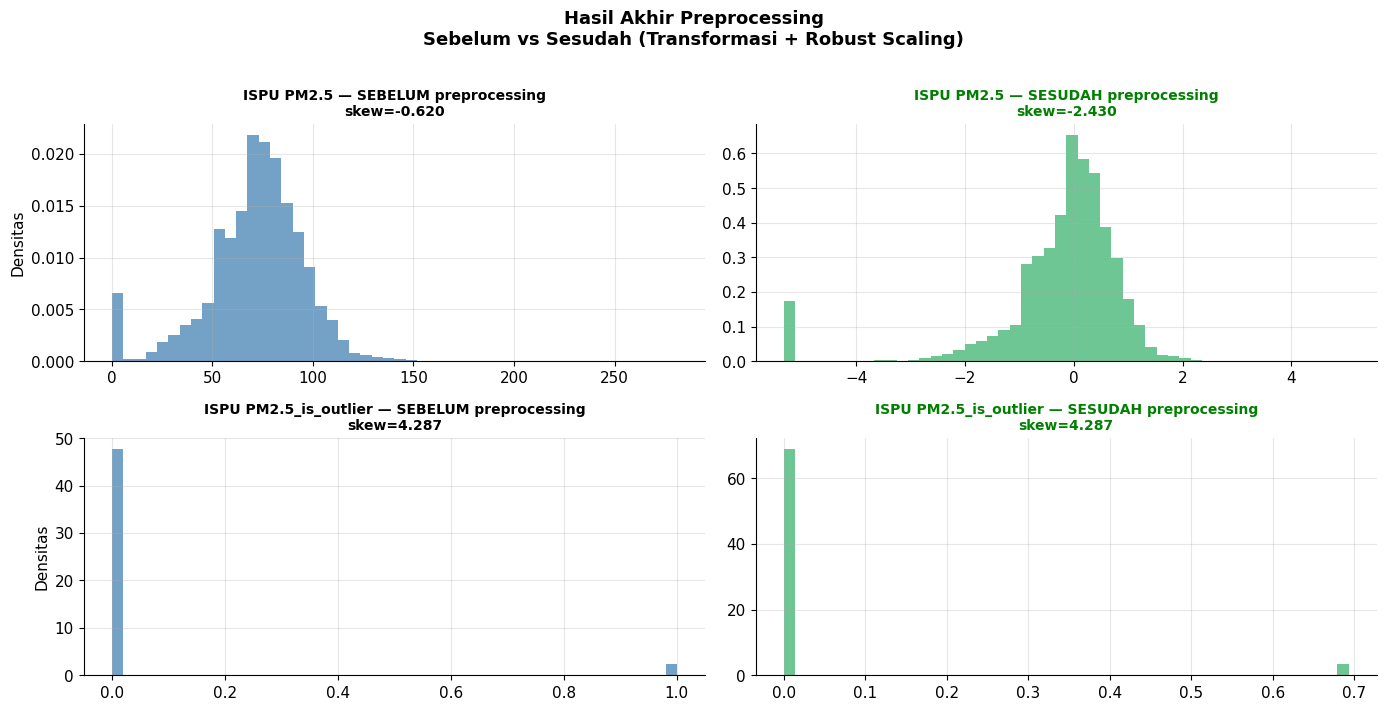

Visualisasi akhir disimpan.


In [23]:
# Visualisasi akhir: Perbandingan distribusi sebelum vs sesudah semua preprocessing
n_pol = min(len(POLLUTANTS), 4)
fig, axes = plt.subplots(n_pol, 2, figsize=(14, n_pol * 3.5))

if n_pol == 1:
    axes = axes.reshape(1, -1)

for i, pol in enumerate(POLLUTANTS[:n_pol]):
    if pol not in df.columns:
        continue
    
    # Sebelum
    axes[i][0].hist(df[pol].dropna(), bins=50, color='steelblue', alpha=0.75, density=True)
    axes[i][0].set_title(f'{pol} — SEBELUM preprocessing\nskew={df[pol].skew():.3f}', 
                          fontweight='bold', fontsize=10)
    axes[i][0].set_ylabel('Densitas')
    axes[i][0].grid(alpha=0.3)
    
    # Sesudah (transformed + scaled)
    col_after = f'{pol}_transformed'
    if col_after in df_scaled.columns:
        axes[i][1].hist(df_scaled[col_after].dropna(), bins=50, 
                         color='mediumseagreen', alpha=0.75, density=True)
        axes[i][1].set_title(f'{pol} — SESUDAH preprocessing\nskew={df_scaled[col_after].skew():.3f}', 
                              fontweight='bold', fontsize=10, color='green')
    elif pol in df_scaled.columns:
        axes[i][1].hist(df_scaled[pol].dropna(), bins=50, 
                         color='mediumseagreen', alpha=0.75, density=True)
        axes[i][1].set_title(f'{pol} — SESUDAH preprocessing\nskew={df_scaled[pol].skew():.3f}', 
                              fontweight='bold', fontsize=10, color='green')
    axes[i][1].grid(alpha=0.3)

plt.suptitle('Hasil Akhir Preprocessing\nSebelum vs Sesudah (Transformasi + Robust Scaling)', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/hasil_akhir_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi akhir disimpan.')

---
##  Ringkasan Keputusan Preprocessing

### Diskretisasi
| Kolom | Metode | Jumlah Bin | Alasan |
|---|---|---|---|
| PM2.5 | ISPU | 5 | Standar resmi Indonesia |
| PM10 | ISPU | 5 | Standar resmi Indonesia |
| SO2, CO, O3, NO2 | ISPU | 5 | Standar resmi Indonesia |

### Transformasi
| Kolom | Skewness Sebelum | Metode | Skewness Sesudah | Alasan |
|---|---|---|---|---|
| PM2.5 | Tulis | Log(x+1) | Tulis | Right-skewed |
| ... | | | | |

### Scaling
| Metode | Fitur yang Discale | Alasan |
|---|---|---|
| RobustScaler | Semua fitur numerik | Data polusi memiliki outlier nyata |

### Feature Engineering
| Fitur Baru | Tipe | Alasan |
|---|---|---|
| jam_sin, jam_cos | Temporal siklus | Menangkap sifat periodik jam |
| is_rush_hour | Binary | Rush hour = sumber polusi utama |
| PM2.5_lag1h ... PM2.5_lag24h | Lag | Autokorelasi kuat pada time series |
| PM2.5_roll_mean_24h | Rolling | Tren jangka pendek |
